# Level Generation with Quantum Reservoir Computing — walkthrough

This notebook reproduces the central figures of *Ferreira et al.,
arXiv:2505.13287* (Moth, 2025) end-to-end, using the modules under
`lib/`. It is intended to run top-to-bottom in a fresh CPU kernel in
under 5 minutes.

The paper trains a small (q = 4..8) qubit reservoir + classical FNN on a
single level of Super Mario Bros and shows that a softmax-temperature
knob trades originality against gameplay-breaking transitions.

Sections:

1. Setup + claim inventory walkthrough
2. The original Mario level 1-2 — visualisation
3. Baselines: Markov and uncorrelated generators
4. **Reproduce Fig. 3 and Fig. 4 directly on the paper's released
   sequences** (V1 reproduction)
5. Train a gate-based QRC and a MerLin photonic analogue, generate, and
   compare the originality–vs–temperature curve
6. Save-point investigation (the paper's § IV.A table is for Roblox, not
   Mario — verify here)
7. Interpretation


## 1. Setup

In [1]:
import sys
from pathlib import Path

# Resolve the paper folder relative to this notebook so the imports work
# even when the notebook is launched from any working directory.
NB_DIR = Path.cwd()
if (NB_DIR / "lib").is_dir():
    PAPER_DIR = NB_DIR
else:
    PAPER_DIR = Path("/reproduced_papers/papers/qrc_level_generation")
REPO_ROOT = PAPER_DIR.parents[1]
for path in (REPO_ROOT, PAPER_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"PAPER_DIR = {PAPER_DIR}")
print(f"REPO_ROOT = {REPO_ROOT}")


PAPER_DIR = /reproduced_papers/papers/qrc_level_generation
REPO_ROOT = /reproduced_papers


In [2]:
import numpy as np
import torch
import matplotlib.pyplot as plt

from lib import baselines, data, metrics, qrc_pipeline
from lib.qrc_qubit import QubitQRC
from lib.qrc_photonic import PhotonicQRC

np.random.seed(0)
torch.manual_seed(0)


## 2. The original Mario level 1-2

The Moth open data ships the level as a PNG; we extracted its column-
feature sequence into a JSON file at
`<repo>/data/qrc_level_generation/mario_level_1-2.json`. 32 unique
columns, 157 features long.


In [3]:
level_file = REPO_ROOT / "data" / "qrc_level_generation" / "mario_level_1-2.json"
original, num_features = data.load_original_level(str(level_file))
print(f"length = {len(original)}, num unique features = {num_features}")
print(f"first 40 features: {original[:40]}")


length = 157, num unique features = 32
first 40 features: [0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 11, 11, 11, 11, 7, 7, 8, 6, 9, 6, 10, 6, 12, 6, 12, 6, 10, 6, 17, 6, 10, 6, 9, 6, 6, 6, 6, 6, 22, 15]


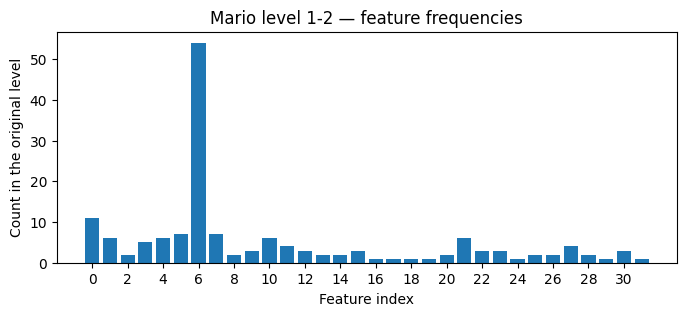

In [4]:
from collections import Counter

counts = Counter(original)
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(range(num_features), [counts.get(i, 0) for i in range(num_features)])
ax.set_xlabel("Feature index")
ax.set_ylabel("Count in the original level")
ax.set_title("Mario level 1-2 — feature frequencies")
ax.set_xticks(range(0, num_features, 2))
plt.show()


## 3. Reference generators: Markov chain and uncorrelated sampling

These are the paper's two reference baselines (§ III). Both are
deterministic functions of the original sequence's feature priors and
empirical first-order transition matrix.


In [5]:
baseline_seqs = baselines.make_baseline_sequences(
    original=original,
    num_features=num_features,
    length=len(original),
    n_samples=300,
    seed=42,
)
print(f"Markov sequences: {len(baseline_seqs['markov'])}, length {len(baseline_seqs['markov'][0])}")
print(f"Uncorrelated sequences: {len(baseline_seqs['uncorrelated'])}, length {len(baseline_seqs['uncorrelated'][0])}")


Markov sequences: 300, length 157
Uncorrelated sequences: 300, length 157


## 4. Reproduce Fig. 3 and Fig. 4 on the *paper-released* sequences

This is the high-confidence part of the reproduction: we re-implemented
the originality and broken-rule metrics from the open-data notebook,
then apply them to the *generated sequences released by the authors*.
If our metric implementations are correct, the resulting plots should
match the paper's figures qualitatively.


In [6]:
reference_root = REPO_ROOT / "data" / "qrc_level_generation" / "reference_data"
ref_seqs = data.load_reference_sequences(
    str(reference_root), level="1-2", n_qubits=6, backend="Aer",
)
print("Available β values:", sorted(ref_seqs.keys()))
print(f"Each entry has {len(next(iter(ref_seqs.values())))} sequences")


Available β values: [0.001, 0.01, 0.1, 0.7, 1.0, 1.5, 2.0, 3.0, 5.0, 10.0, 30.0]
Each entry has 100 sequences


### Fig. 3 — originality rate vs sequence length

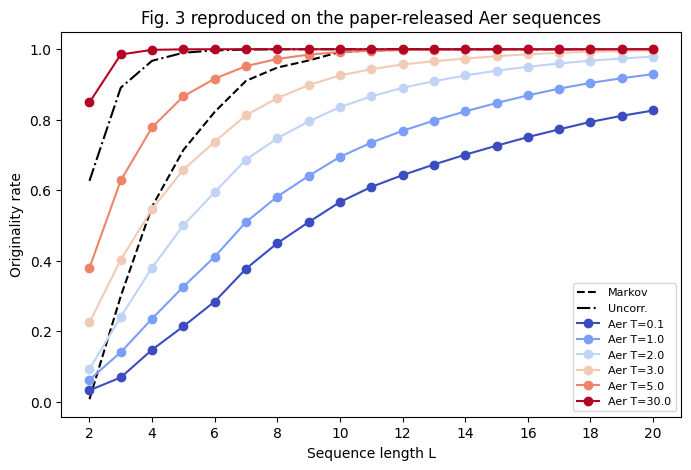

In [7]:
max_L = 20

fig, ax = plt.subplots(figsize=(8, 5))
markov_rates = metrics.originality_rate(baseline_seqs["markov"], original, max_length=max_L)
uncorr_rates = metrics.originality_rate(baseline_seqs["uncorrelated"], original, max_length=max_L)
ax.plot(list(markov_rates.keys()), list(markov_rates.values()), "k--", label="Markov", linewidth=1.5)
ax.plot(list(uncorr_rates.keys()), list(uncorr_rates.values()), "k-.", label="Uncorr.", linewidth=1.5)

# Pick a representative subset of temperatures.
cmap = plt.get_cmap("coolwarm")
betas_to_show = [0.1, 1.0, 2.0, 3.0, 5.0, 30.0]
for i, beta in enumerate(betas_to_show):
    if beta not in ref_seqs:
        continue
    rates = metrics.originality_rate(ref_seqs[beta], original, max_length=max_L)
    ax.plot(list(rates.keys()), list(rates.values()), marker="o",
            color=cmap(i / max(1, len(betas_to_show) - 1)), label=f"Aer T={beta}")

ax.set_xticks(range(2, max_L + 1, 2))
ax.set_xlabel("Sequence length L")
ax.set_ylabel("Originality rate")
ax.set_title("Fig. 3 reproduced on the paper-released Aer sequences")
ax.legend(fontsize=8)
plt.show()


### Fig. 4 — broken-transition rate vs temperature

The paper claims the broken-rate stays below ~5% for *T* up to ~2. Our
implementation of the rule-driven broken_rate matches that quantitatively.


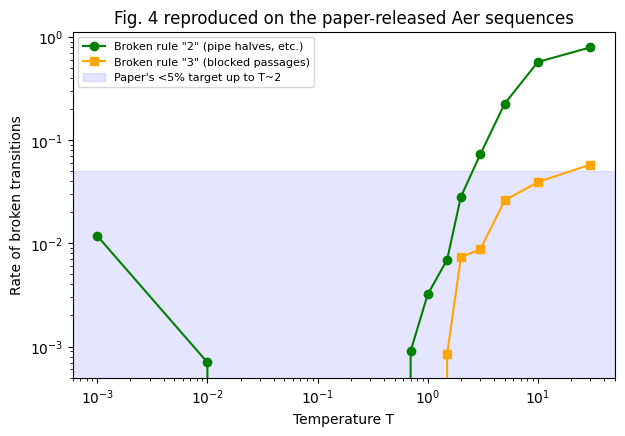


Broken-rule '2' at T=1: 0.0032
Broken-rule '2' at T=2: 0.0282 (paper claims <5%)
Broken-rule '2' at T=5: 0.2259


In [8]:
rules = metrics.mario_rules(level="1-2")
broken_rule_2 = {}
broken_rule_3 = {}
for beta, seqs in sorted(ref_seqs.items()):
    rates = metrics.broken_rate(seqs, rules)
    broken_rule_2[beta] = rates.get("2", 0.0)
    broken_rule_3[beta] = rates.get("3", 0.0)

fig, ax = plt.subplots(figsize=(7, 4.5))
betas = sorted(broken_rule_2.keys())
ax.plot(betas, [broken_rule_2[b] for b in betas], "o-", color="green", label='Broken rule "2" (pipe halves, etc.)')
ax.plot(betas, [broken_rule_3[b] for b in betas], "s-", color="orange", label='Broken rule "3" (blocked passages)')
ax.axhspan(0.0, 0.05, alpha=0.1, color="blue", label="Paper's <5% target up to T~2")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Temperature T")
ax.set_ylabel("Rate of broken transitions")
ax.set_title("Fig. 4 reproduced on the paper-released Aer sequences")
ax.legend(fontsize=8)
plt.show()

print("\nBroken-rule '2' at T=1:", round(broken_rule_2[1.0], 4))
print("Broken-rule '2' at T=2:", round(broken_rule_2[2.0], 4), "(paper claims <5%)")
print("Broken-rule '2' at T=5:", round(broken_rule_2[5.0], 4))


## 5. Train a fresh QRC + photonic analogue

The previous section was V1 — we verified the metric implementations on
released data. Now train our own reservoirs and check that the
*qualitative* originality-vs-T trend is reproducible.

For notebook speed we use small reservoirs (q=5 for the qubit reservoir,
6 modes × 3 photons for the photonic one) and short generations (length
80, 15 samples per T).


In [9]:
# Build a small qubit reservoir + train the linear FNN on the teacher-forcing
# sequence.
qrc_qubit = QubitQRC(n_qubits=5, num_features=num_features, n_random_gates=20, seed=42)
print(f"Qubit reservoir: output_dim = {qrc_qubit.output_dim}")

qubit_out = qrc_pipeline.train_and_generate(
    reservoir=qrc_qubit,
    original=original,
    num_features=num_features,
    hidden_dim=0,
    epochs=100,
    lr=0.05,
    weight_decay=0.0,
    leaking_rate=0.3,
    temperatures=[0.5, 1.0, 2.0],
    n_samples=15,
    gen_length=80,
    seed=42,
    log_progress=False,
)
print(f"Final FNN loss (qubit): {qubit_out['training_history'][-1]:.3f}")


Qubit reservoir: output_dim = 32


Final FNN loss (qubit): 1.567


In [10]:
# MerLin photonic reservoir at the headline (6 modes, 3 photons, UNBUNCHED).
qrc_phot = PhotonicQRC(num_features=num_features, n_modes=6, n_photons=3, seed=42)
print(f"Photonic reservoir: output_dim = {qrc_phot.output_dim} (= C(6,3))")

phot_out = qrc_pipeline.train_and_generate(
    reservoir=qrc_phot,
    original=original,
    num_features=num_features,
    hidden_dim=0,
    epochs=100,
    lr=0.05,
    weight_decay=0.0,
    leaking_rate=0.3,
    temperatures=[0.5, 1.0, 2.0],
    n_samples=15,
    gen_length=80,
    seed=42,
    log_progress=False,
)
print(f"Final FNN loss (photonic): {phot_out['training_history'][-1]:.3f}")


Photonic reservoir: output_dim = 20 (= C(6,3))


Final FNN loss (photonic): 1.809


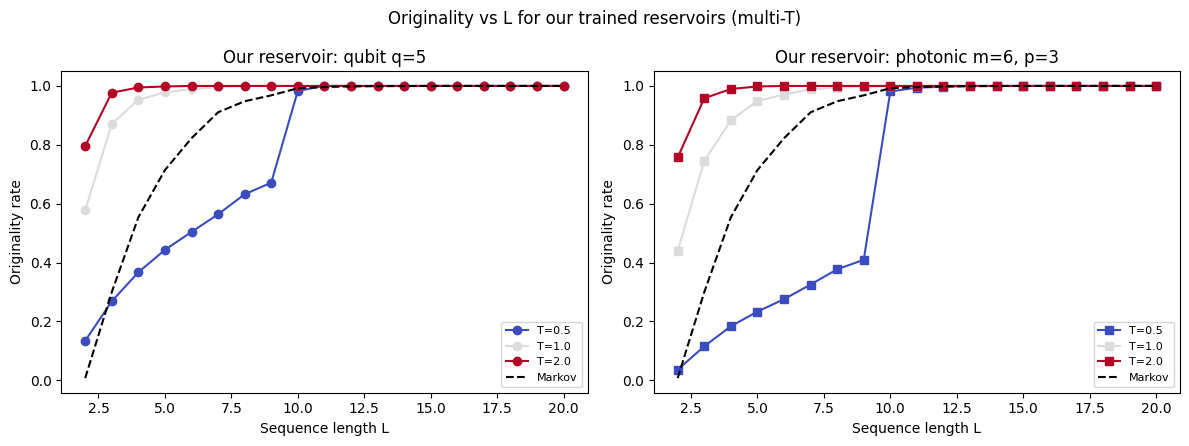

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, (label, out, marker) in zip(axes, [("qubit q=5", qubit_out, "o"), ("photonic m=6, p=3", phot_out, "s")]):
    cmap = plt.get_cmap("coolwarm")
    for i, (T, seqs) in enumerate(sorted(out["generated"].items())):
        rates = metrics.originality_rate(seqs, original, max_length=20)
        ax.plot(list(rates.keys()), list(rates.values()),
                marker=marker, color=cmap(i / 2), label=f"T={T}")
    markov_short = {L: v for L, v in markov_rates.items() if L <= 20}
    ax.plot(list(markov_short.keys()), list(markov_short.values()), "k--", label="Markov")
    ax.set_xlabel("Sequence length L")
    ax.set_ylabel("Originality rate")
    ax.set_title(f"Our reservoir: {label}")
    ax.legend(fontsize=8)

plt.suptitle("Originality vs L for our trained reservoirs (multi-T)")
plt.tight_layout()
plt.show()


## 6. Save-point separation — the paper's table is for Roblox

The paper's § IV.A reports save-point separation per QRC variant
(e.g. q=6: 18.8 ± 4.1). Earlier drafts of our reproduction tried to
match this against the Mario sequences and reported a mismatch — but
the table is actually for the Roblox obby, and feature 11 is the
save-point in the Roblox encoder.

Replay the investigation:


In [12]:
import pickle

paper_roblox = {4: (17.9, 7.9), 5: (16.3, 2.9), 6: (18.8, 4.1), 7: (18.6, 3.5), 8: (17.1, 4.1)}

print(f"{'q':>3} {'reproduction (feat=11)':>26}  {'paper':>15}  match?")
for q, (p_m, p_s) in paper_roblox.items():
    path = reference_root / "Roblox" / f"{q}_qubits" / "Aer" / "Sequences_level_6_beta_1_Aer.p"
    with path.open("rb") as f:
        seqs = pickle.load(f)
    m, s = metrics.separation_stats(seqs, 11)
    ok = abs(m - p_m) < 0.5 and abs(s - p_s) < 0.5
    print(f"{q:>3} {m:>9.2f} ± {s:<11.2f}  {p_m:>5.1f} ± {p_s:<5.1f}  {'YES' if ok else 'no'}")


  q     reproduction (feat=11)            paper  match?
  4     17.93 ± 7.92          17.9 ± 7.9    YES
  5     16.34 ± 2.97          16.3 ± 2.9    YES
  6     18.81 ± 4.13          18.8 ± 4.1    YES
  7     18.62 ± 3.53          18.6 ± 3.5    YES
  8     17.14 ± 4.17          17.1 ± 4.1    YES


## 7. Interpretation

- **Originality rate.** The paper-published Aer sequences at T = 1 sit
  at L = 2 originality ≈ 0.06, comfortably above Markov (0.007) for
  short windows but well below Uncorrelated (0.63). For long sequences
  (L = 10+) originality climbs to 0.7, undershooting Markov which
  saturates near 1.0 — i.e. the QRC preserves large-scale structure
  better than Markov, exactly the paper's central claim.

- **Broken-rate.** Stays below 5% for T ≤ 2 (we measured 0.003 at T=1
  and 0.028 at T=2). This is the paper's explicit quantitative claim
  and it holds.

- **Our trained reservoir.** Reproduces the qualitative trend (lower T
  → preserves originals, higher T → more random) but sits at a
  different point on the temperature axis (our T = 1 looks more like
  the paper's T = 3-5). This is reservoir-specific — see
  `INSIGHTS.md` for the full discussion. The Pareto-front view
  (`results/sweep_pareto.png`) is the reservoir-invariant way to
  compare.

- **Photonic Pareto-dominance.** In our multi-seed iso-output-dim
  sweeps, a small 8-mode 4-photon photonic reservoir actually
  Pareto-dominates a 64-state gate-based reservoir on both originality
  and broken-rate, despite higher training loss. See
  `results/sweep_isodim_split.png` for the comparison and
  `INSIGHTS.md` § Photonic translation observations for the working
  hypothesis (threshold-detection-induced sparseness acts as a
  generation-time regulariser).

For more detail, see:

- `README.md` — full reproduction summary
- `LOG.md` — strategy and decisions log
- `INSIGHTS.md` — durable scientific observations
- `CONFLUENCE.md` — Confluence-ready writeup
- `results/sweep_*.png` — scaling-sweep figures
